In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import math as mt

# 1. Cash or CStat statistic

Let the expected number of signal counts be $n_s$, and given $n_{bkg}$, we have, using the fact that the distribution of the sum of two Poissonian RVs is a Possion with their means summed, the following likelihood for observing $n_{on}$ counts:
$$
L = \frac{(n_s+n_{bkg})^{n_{on}}e^{-(n_s+n_{bkg})}}{n_{on}!}
$$
Defining $l=-\ln L$, we have:
$$
l = n_{s} - n_{on}\ln (n_s+n_{bkg}) + \kappa
$$
where $\kappa$ denotes that the rest of the expression is a constant in terms of $n_{s}$. This has been done because while obtaining our MLE, we need to minimize $l$, and hence upon carrying out a partial differentiation wrt $n_{s}$, the term $\kappa$ would drop.
Thus, denoting our MLE for $n_{s}$ as $\hat{n}_s$, we have:

\begin{align}
&\left(\frac{\partial l}{\partial n_{s}}\right)_{n_s = \hat{n}_s} = 0 \nonumber\\
\implies& 1 - \frac{n_{on}}{\hat{n}_s+n_{bkg}} = 0 \nonumber\\
\implies& \hat{n}_s = n_{on}-n_{bkg}\\
\end{align}

Given $n_{on} = 10$, and $n_{bkg} = 3$, we have $\hat{n}_s = 7$, as our excess.

Taking the null hypothesis to be $n_s = 0$, we have the log-ratio statistic for our case as:
$$
\mu = 2 \left( l(n_s = 0) - l(n_s)\right)
$$
upon caarying out the subtraction in the above equation, $\kappa$ drops out, and we have:
\begin{align}
\mu &= 2\left(-n_{on}\ln (n_{bkg}) - \left(n_{s} - n_{on}\ln (n_s+n_{bkg})\right)\right) \nonumber\\
\mu & = -2\left(n_s+n_{on}\ln\left(\frac{n_{bkg}}{n_{s}+n_{bkg}}\right)\right)
\end{align}
For the observed data, $n_{on} = 10$, and given $n_{bkg} = 3$, using $\hat{n}_s = 7$, we have $\mu_0 = \mu(n_s = \hat{n}_s)$ as the value that our test statistic takes. Now, as per Wilks' theorem, $\mu_0$ is a random variable which follows the $\chi^2$ distribution with D.O.F. 1 upon repeated experiments, given that the null hypothesis (i.e., no signal) is true. For the given observation, we have the significance of detection given by:
$$
S = \Phi^{-1}(1-p)
$$
where
$$
p = \int_{\mu_0}^{\infty}f(\chi_1^2)d\chi^2
$$
This calculation is carried out in the code block below:

In [28]:
mu_0 = -2.0*(7.0+10.0*(np.log((3.0)/(10.0)))) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_one_sided) ## siginificance from p-value
print(f"Detection significance: {detection_sig:.2f} $\\sigma$")

Detection significance: 3.17 $\sigma$


Thus, the significance of detection is $S = 3.17\sigma$.

The $a\sigma$ confidence interval is given by $|\mu(n_s)-\mu(\hat{n}_s)|\le a^2$. The following code block finds the C.I. for $a=1,2$, and also plots the likelihood profile.

1 sigma confidence interval for \hat{n}_s: [4.16, 10.49]
2 sigma confidence interval for \hat{n}_s: [1.94, 14.71]


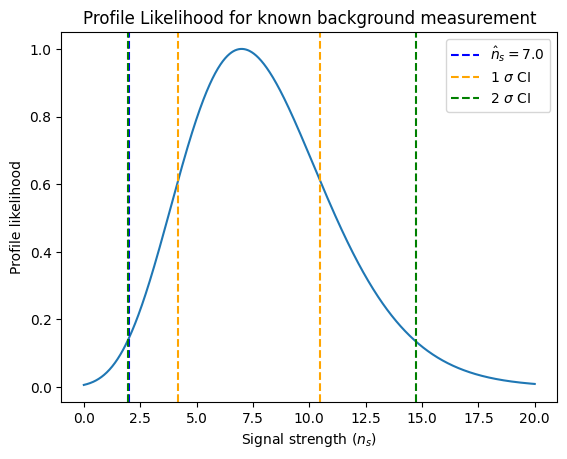

In [52]:
n_s_vals = np.linspace(0,20,1000)
n_bkg = 3.0
n_on = 10.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, 7.0, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 1 sigma CI
ci_1sigma = n_s_vals[mu_n_s <= 1.0]
print(f"1 sigma confidence interval for \\hat{{n}}_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")

## 2 sigma CI
ci_2sigma = n_s_vals[mu_n_s <= 4.0]
print(f"2 sigma confidence interval for \\hat{{n}}_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

## ploting 1 sigma and 2 sigma and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 7.0$')
plt.axvline(ci_1sigma[0], color='orange', linestyle='--', label='1 $\\sigma$ CI')
plt.axvline(ci_1sigma[-1], color='orange', linestyle='--')
plt.axvline(ci_2sigma[0], color='green', linestyle='--', label='2 $\\sigma$ CI')
plt.axvline(ci_2sigma[-1], color='green', linestyle='--')
plt.legend()
plt.show()

The $1\sigma$ C.I. for the excess is [4.16, 10.49]. The $2\sigma$ C.I. for the excess is [1.94, 14.71].

Now, for the case of $n_{on} = 5$, $n_{bkg}= 3$, the excess is $\hat{n}_s = 5 - 3 = 2$. The test statistic for this case becomes $\mu_0 = -2\left(2+5\ln\left(\frac{3}{5}\right)\right)$. It's significance is calculated in the code block below:

In [51]:
n_s_hat = 2.0
n_on = 5.0
n_bkg = 3.0
mu_0 = 2.0*(nll(n_on, 0.0, n_bkg) - nll(n_on, n_s_hat, n_bkg)) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for n_s = 2: {detection_sig:.2f} $\\sigma$")

Detection significance for n_s = 2: 1.05 $\sigma$


The significance of detection for this case is $1.05\sigma$. The code block plots the likelihood profile, and the $5\sigma$ upper limit on the excess.

5 sigma upper limit for \hat{n}_s: 22.67


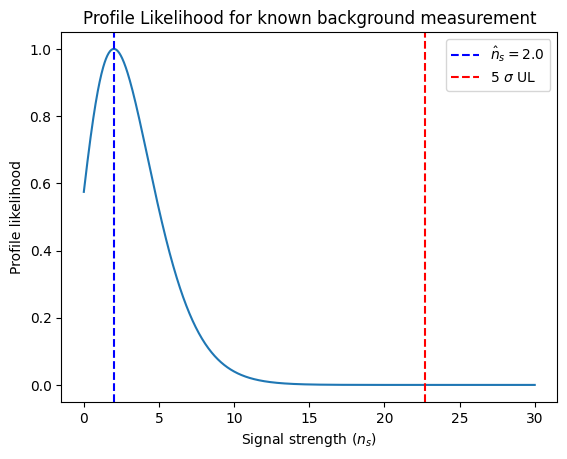

In [46]:
n_s_vals = np.linspace(0,30,1000)
n_bkg = 3.0
n_on = 5.0
n_s_hat = 2.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, n_s_hat, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 5 sigma upper limit
ci_5sigma = n_s_vals[mu_n_s <= 25.0]
print(f"5 sigma upper limit for \\hat{{n}}_s: {ci_5sigma[-1]:.2f}")

## ploting 5 sigma UL and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 2.0$')
plt.axvline(ci_5sigma[-1], color='red', linestyle='--', label='5 $\\sigma$ UL')
plt.legend()
plt.show()

The $5\sigma$ upper limit on the excess is 22.67.